## Pipeline XGBoost por poço - Modelo preditivo de profundidade de água subterrânea

**Objetivo:** Modelar e prever a profundidade do nível de água subterrânea (`profundidade`) por poço (`codigo`) usando modelos de regressão XGBoost com variáveis exógenas e divisão temporal (train/test no tempo).

### Características principais
- **Mesma estrutura de dados do `modelo1.ipynb`** (mesmo CSV, mesmas colunas, mesmo pré-processamento mensal por poço).
- **Variável alvo:** `profundidade` (metros).
- **Variáveis exógenas:** apenas os 6 lags (`rr_lag1`, `rr_lag2`, `eto_lag1`, `eto_lag2`, `caudal_lag1`, `caudal_lag2`).
- **Split temporal:** últimos 20% dos dados de cada poço para teste.
- **Modelo:** `XGBRegressor` por poço (um modelo por `codigo`).
- **Baseline:** persistência (prevê sempre o valor anterior `y_{t-1}`).
- **Métricas:** RMSE, MAE, MAPE, R² e comparação com baseline.

### 🆕 Melhorias implementadas com Cross-Validation
- **Time Series Cross-Validation:** avaliação robusta respeitando ordem temporal (nunca usa dados futuros)
- **Seleção de features por poço:** cada poço tem suas próprias features otimizadas usando CV
- **Tuning de hiperparâmetros por poço:** hiperparâmetros ajustados individualmente para cada poço usando CV
- **Comparação automática:** compara modelo otimizado vs modelo original para medir melhorias



**Explicação:** Esta célula importa todas as bibliotecas necessárias e define funções auxiliares para calcular métricas de avaliação do modelo:

- **Bibliotecas:** numpy, pandas, sklearn, xgboost, matplotlib, tqdm
- **Funções de métricas:**
  - `rmse()`: Calcula o Root Mean Squared Error (raiz quadrada do erro médio quadrático)
  - `mape()`: Calcula o Mean Absolute Percentage Error (erro percentual médio absoluto)
  - `r2_score()`: Calcula o coeficiente de determinação R²

Estas métricas serão usadas para avaliar a qualidade das previsões do modelo XGBoost.

---

<div style="background-color: #e3f2fd; color: #000000; padding: 15px; border-left: 4px solid #2196F3; margin: 10px 0;">

**📚 Teórica:**

**RMSE (Root Mean Squared Error):** Mede a raiz quadrada da média dos erros ao quadrado. Matematicamente: RMSE = √(Σ(y_true - y_pred)² / n). Penaliza mais erros grandes devido ao quadrado, sendo sensível a outliers. Unidades: mesma da variável alvo (metros, neste caso).

**MAPE (Mean Absolute Percentage Error):** Erro percentual médio absoluto. Fórmula: MAPE = (100/n) × Σ|y_true - y_pred| / |y_true|. Útil para comparar erros entre séries com escalas diferentes, mas pode ser problemático quando y_true ≈ 0.

**R² (Coeficiente de Determinação):** Mede a proporção da variância da variável dependente explicada pelo modelo. Fórmula: R² = 1 - (SS_res / SS_tot), onde SS_res é a soma dos quadrados dos resíduos e SS_tot é a soma total dos quadrados. Valores próximos de 1 indicam bom ajuste, valores negativos indicam que o modelo é pior que a média simples.(R^2 é sempre positivo, o R^2 adjusted é que pode ser negativo)

</div>


In [1]:
import warnings
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
except Exception as e:
    raise ImportError(
        "xgboost é necessário para este notebook. Instale com: pip install xgboost"
    ) from e

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Error"""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Mean Absolute Percentage Error (em percentagem)."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def r2_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """R² Score (coeficiente de determinação)."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return np.nan
    return float(1 - (ss_res / ss_tot))



**Explicação:** Esta célula define todas as configurações e parâmetros do modelo:

- **Caminho do CSV:** Localização do ficheiro de dados
- **Colunas principais:** Identificação do poço (`codigo`), data (`ym`), variável alvo (`profundidade`)
- **Poços selecionados:** Lista de 17 poços específicos para modelação
- **Variáveis exógenas:** Apenas os 6 lags (precipitação, evapotranspiração e caudal com 1 e 2 meses de atraso)
- **Parâmetros de split:** 20% dos dados para teste, mínimo de 24 observações por poço
- **Hiperparâmetros XGBoost padrão:** Configuração inicial do modelo (n_estimators, learning_rate, max_depth, etc.)

Estes parâmetros podem ser ajustados conforme necessário.


In [2]:
# Configuração

CSV_PATH = "/Users/diogopinto/Documents/Pessoal/path_4med/eobs_netcdf/usar_model/correlacao_matriz/modelo_1/mensal_por_poco_full_valores_lags_este.csv"

# Colunas principais
ID_COL = "codigo"
DATE_COL = "ym"
TARGET_COL = "profundidade"

# Lista de poços a modelar (os restantes serão ignorados)
SELECTED_WELLS = [
    "391/33",
    "377/94",
    "330/183",
    "405/17",
    "377/86",
    "341/17",
    "418/4",
    "391/437",
    "404/69",
    "391/243",
    "342/78",
    "331/2",
    "405/34",
    "390/208",
    "377/54",
    "342/97",
    "377/84",
]

# Variáveis exógenas: APENAS os 6 lags (rr_lag1, rr_lag2, eto_lag1, eto_lag2, caudal_lag1, caudal_lag2)
XREG_COLS = [
    "rr_lag1", "rr_lag2",
    "eto_lag1", "eto_lag2",
    "caudal_lag1", "caudal_lag2",
]

# Variáveis base (apenas para interpolação se necessário, mas não usadas diretamente no modelo)
BASE_EXOG_COLS = ["rr", "eto", "caudal"]

# Parâmetros gerais
TEST_FRACTION = 0.20   # últimos 20% para teste
MIN_SERIES_LENGTH = 24 # mínimo de observações por poço
SEASONAL_PERIOD = 12   # mantido apenas para referência (não usado diretamente pelo XGBoost)

RANDOM_SEED = 42
N_JOBS = -1

# Hiperparâmetros padrão do XGBoost (podem ser ajustados)
XGB_PARAMS = dict(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=RANDOM_SEED,
    n_jobs=N_JOBS,
)



**Explicação:** Esta célula carrega e prepara os dados para modelação:

1. **Carregamento do CSV:** Lê o ficheiro de dados e converte a coluna de data
2. **Reindex mensal:** Preenche gaps mensais nos dados, criando uma série temporal completa mensal por poço
3. **Tratamento de NAs:**
   - Interpola valores faltantes nas variáveis base (rr, eto, caudal) usando interpolação linear
   - Remove linhas com NAs nas variáveis de lag (necessárias para o modelo)
   - Remove linhas com NAs na variável alvo (profundidade)
4. **Filtragem:** Mantém apenas os poços selecionados na lista `SELECTED_WELLS`

O resultado é um DataFrame limpo e completo, pronto para modelação.


In [3]:
# Carregamento e preparação dos dados (mesma lógica do modelo1)

# 1) Ler CSV

df = pd.read_csv(CSV_PATH)

# Converter coluna de data se necessário
if not np.issubdtype(df[DATE_COL].dtype, np.datetime64):
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

# Selecionar e ordenar colunas relevantes
expected_cols = [ID_COL, DATE_COL, TARGET_COL] + XREG_COLS + BASE_EXOG_COLS
missing_cols = [c for c in expected_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Colunas em falta no CSV: {missing_cols}")

# Subconjunto de colunas necessárias
df = df[[ID_COL, DATE_COL, TARGET_COL] + XREG_COLS + BASE_EXOG_COLS].copy()
df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

print(f"CSV carregado: {len(df)} linhas, {df[ID_COL].nunique()} poços únicos")
print(f"Variáveis exógenas para o modelo (lags): {XREG_COLS}")

# 2) Funções para verificar gaps mensais e fazer reindex mensal por poço

def has_month_gaps(group: pd.DataFrame) -> bool:
    dates = group[DATE_COL].sort_values()
    if dates.empty:
        return False
    start = dates.min().to_period("M")
    end = dates.max().to_period("M")
    full = pd.period_range(start, end, freq="M")
    return len(dates) != len(full)


wells_with_gaps = df.groupby(ID_COL, group_keys=False)[DATE_COL].apply(
    lambda dates: has_month_gaps(pd.DataFrame({DATE_COL: dates}))
)
num_wells_with_gaps = int(wells_with_gaps.sum())


def reindex_monthly(group: pd.DataFrame) -> pd.DataFrame:
    dates = group[DATE_COL].sort_values()
    if dates.empty:
        return group
    start = dates.min().to_period("M").to_timestamp()
    end = dates.max().to_period("M").to_timestamp()
    full_idx = pd.date_range(start, end, freq="MS")

    codigo_val = group[ID_COL].iloc[0]

    g2 = group.set_index(DATE_COL).reindex(full_idx)
    g2.index.name = DATE_COL
    g2[ID_COL] = codigo_val
    return g2.reset_index()


# 3) Reindex mensal por poço

df_list = []
for codigo, group in df.groupby(ID_COL, group_keys=False):
    reindexed = reindex_monthly(group)
    df_list.append(reindexed)

df = pd.concat(df_list, ignore_index=True)
df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

# 4) Tratar NAs

# 4.1) Interpolar variáveis base (rr, eto, caudal) se necessário
for c in BASE_EXOG_COLS:
    if c in df.columns:
        df[c] = (
            df.groupby(ID_COL, group_keys=False)[c]
              .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
        )

# 4.2) Remover linhas com NA nas variáveis de lag (XREG_COLS)
df = df.dropna(subset=XREG_COLS)

# 4.3) Remover linhas com NA na variável alvo
df = df.dropna(subset=[TARGET_COL])

# 5) Ordenar e filtrar apenas poços selecionados

df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

if SELECTED_WELLS:
    df = df[df[ID_COL].isin(SELECTED_WELLS)].copy()

print({
    "rows_after_clean": len(df),
    "unique_wells": df[ID_COL].nunique(),
    "wells_with_gaps_pre_reindex": num_wells_with_gaps,
    "filtered_wells": df[ID_COL].nunique(),
})

df.head()



CSV carregado: 22119 linhas, 73 poços únicos
Variáveis exógenas para o modelo (lags): ['rr_lag1', 'rr_lag2', 'eto_lag1', 'eto_lag2', 'caudal_lag1', 'caudal_lag2']
{'rows_after_clean': 2356, 'unique_wells': 17, 'wells_with_gaps_pre_reindex': 0, 'filtered_wells': 17}


,ym,codigo,profundidade,rr_lag1,rr_lag2,eto_lag1,eto_lag2,caudal_lag1,caudal_lag2,rr,eto,caudal
15,2000-03-01,330/183,7.46,1.900000,23.800002,2.128276,1.373548,90.410000,185.302903,28.200000,3.239677,66.979677
16,2000-04-01,330/183,7.29,28.200000,1.900000,3.239677,2.128276,66.979677,90.410000,175.200004,2.909667,144.695000
17,2000-05-01,330/183,6.66,175.200004,28.200000,2.909667,3.239677,144.695000,66.979677,87.600002,4.611613,356.501613
18,2000-06-01,330/183,7.50,87.600002,175.200004,4.611613,2.909667,356.501613,144.695000,0.000000,6.125667,78.218667
19,2000-07-01,330/183,8.40,0.000000,87.600002,6.125667,4.611613,78.218667,356.501613,9.200000,6.178387,82.856129


**Explicação:** Esta célula define funções auxiliares para o processo de modelação:

- **`temporal_split()`:** Divide os dados em treino e teste mantendo a ordem temporal (nunca usa dados futuros para prever o passado). Os últimos 20% dos dados vão para teste.

- **`fit_predict_xgboost()`:** Função que treina um modelo XGBoost e faz previsões:
  - Recebe dados de treino e teste
  - Treina o modelo com os dados de treino
  - Retorna o modelo treinado e as previsões para o conjunto de teste

Estas funções serão usadas repetidamente no loop de modelação por poço.

---

<div style="background-color: #e3f2fd; color: #000000; padding: 15px; border-left: 4px solid #2196F3; margin: 10px 0;">

**📚 Teórica:**

**Split Temporal:** Em séries temporais, é fundamental manter a ordem cronológica. O split temporal garante que dados de treino (t < T) nunca sejam usados para prever dados de teste (t ≥ T), evitando "data leakage" que inflacionaria artificialmente a performance.

**XGBoost (eXtreme Gradient Boosting):** Algoritmo de ensemble que combina múltiplas árvores de decisão fracas através de boosting. Funciona iterativamente: cada nova árvore corrige os erros das anteriores. A função objetivo minimiza: L(θ) = Σ l(y_i, ŷ_i) + Σ Ω(f_k), onde l é a função de perda (squared error para regressão), e Ω é a regularização (L1/L2) que penaliza complexidade. O gradiente é calculado usando derivadas de segunda ordem (Hessian) para otimização mais eficiente. Hiperparâmetros principais: `max_depth` (profundidade das árvores), `learning_rate` (shrinkage), `n_estimators` (número de árvores), `subsample` (fração de amostras por árvore).

</div>


In [4]:
# Helpers: split temporal e treino/predição com XGBoost


def temporal_split(group: pd.DataFrame, test_fraction: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Divide um DataFrame em treino e teste, mantendo ordem temporal."""
    n = len(group)
    n_test = max(1, int(round(n * test_fraction)))
    split_idx = n - n_test
    return group.iloc[:split_idx].copy(), group.iloc[split_idx:].copy()


def fit_predict_xgboost(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = TARGET_COL,
    xgb_params: dict | None = None,
):
    """Ajusta um XGBRegressor e devolve o modelo e previsões para o conjunto de teste."""
    if xgb_params is None:
        xgb_params = XGB_PARAMS

    X_train = train_df[feature_cols].to_numpy()
    y_train = train_df[target_col].to_numpy()
    X_test = test_df[feature_cols].to_numpy()

    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    return model, np.asarray(y_pred)



**Explicação:** Esta célula implementa as funções de **Cross-Validation (CV) e otimização** - a parte mais importante do notebook:

1. **`time_series_cv_split()`:** Gera splits temporais para CV respeitando a ordem temporal (nunca usa dados futuros para prever o passado)

2. **`evaluate_model_cv()`:** Avalia um modelo usando Time Series Cross-Validation:
   - Divide os dados em múltiplos splits temporais
   - Treina e avalia o modelo em cada split
   - Retorna métricas médias e desvios padrão (RMSE, MAE, R²)

3. **`select_features_for_well()`:** Seleciona as melhores features para cada poço:
   - Testa diferentes combinações de features usando CV
   - Retorna a combinação que dá menor RMSE no CV

4. **`tune_hyperparameters_for_well()`:** Ajusta hiperparâmetros específicos para cada poço:
   - Testa diferentes combinações de hiperparâmetros (max_depth, learning_rate, n_estimators, subsample)
   - Usa CV para avaliar cada combinação
   - Retorna os hiperparâmetros que dão melhor performance no CV

**Porquê isto é importante?** Cada poço pode ter características diferentes, então otimizar features e hiperparâmetros individualmente melhora significativamente a qualidade das previsões.

---

<div style="background-color: #e3f2fd; color: #000000; padding: 15px; border-left: 4px solid #2196F3; margin: 10px 0;">

**📚 Teórica:**

**Time Series Cross-Validation:** Diferente de CV tradicional (k-fold aleatório), o CV temporal respeita a ordem cronológica. Para cada split i, treina com dados até t_i e testa em t_{i+1} até t_{i+k}. Garante que nunca se usa informação futura para prever o passado, simulando condições reais de previsão. A métrica final é a média das métricas de todos os splits: RMSE_CV = (1/K) × Σ RMSE_i, com desvio padrão para medir variabilidade.

**Seleção de Features (Feature Selection):** Processo de encontrar o subconjunto ótimo de variáveis preditoras. Método usado: busca exaustiva (ou heurística) testando combinações de features e avaliando cada uma com CV. Critério de otimização: minimizar RMSE médio no CV. Para cada combinação S de features, calcula-se: RMSE_CV(S) = (1/K) × Σ RMSE(S, split_k). A combinação S* que minimiza RMSE_CV é selecionada. Isto reduz overfitting e melhora interpretabilidade.

**Tuning de Hiperparâmetros (Grid Search com CV):** Busca no espaço de hiperparâmetros θ = {max_depth, learning_rate, n_estimators, subsample}. Para cada combinação θ_i, treina o modelo e avalia com CV: score(θ_i) = RMSE_CV(θ_i). Seleciona θ* = argmin(θ) score(θ). Limita-se a 20 combinações para eficiência computacional. O processo é custoso mas essencial: hiperparâmetros mal escolhidos podem degradar significativamente a performance.

</div>


In [5]:
# ============================================================================
# TIME SERIES CROSS-VALIDATION E OTIMIZAÇÃO POR POÇO
# ============================================================================
# Esta célula implementa:
# 1. Time Series Cross-Validation (respeitando ordem temporal)
# 2. Seleção de features por poço (cada poço pode ter features diferentes)
# 3. Tuning básico de hiperparâmetros usando CV
# ============================================================================

from itertools import combinations
from sklearn.model_selection import TimeSeriesSplit

# Configurações de CV e otimização
CV_N_SPLITS = 5  # número de splits para cross-validation
MIN_TRAIN_SIZE = 12  # tamanho mínimo do conjunto de treino em cada split
MIN_FEATURES = 2  # número mínimo de features a testar
MAX_FEATURES_TO_TEST = 6  # número máximo de combinações de features a testar (para não demorar muito)

# Espaço de hiperparâmetros para tuning (por poço)
HYPERPARAM_GRID = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [300, 500, 700],
    'subsample': [0.7, 0.8, 0.9],
}

print("=" * 60)
print("CONFIGURAÇÃO DE CROSS-VALIDATION E OTIMIZAÇÃO")
print("=" * 60)
print(f"Número de splits CV: {CV_N_SPLITS}")
print(f"Tamanho mínimo de treino por split: {MIN_TRAIN_SIZE}")
print(f"Features mínimas por modelo: {MIN_FEATURES}")
print(f"Espaço de hiperparâmetros: {len(HYPERPARAM_GRID['max_depth']) * len(HYPERPARAM_GRID['learning_rate']) * len(HYPERPARAM_GRID['n_estimators']) * len(HYPERPARAM_GRID['subsample'])} combinações")

def time_series_cv_split(n_samples, n_splits=CV_N_SPLITS, min_train_size=MIN_TRAIN_SIZE):
    """
    Gera splits temporais para cross-validation.
    Garante que nunca usa dados futuros para prever o passado.
    """
    splits = []
    # Garantir que temos dados suficientes
    if n_samples < min_train_size + 1:
        return splits
    
    # Calcular tamanho mínimo do teste (pelo menos 1)
    min_test_size = max(1, n_samples // (n_splits + 1))
    
    for i in range(n_splits):
        # Tamanho do conjunto de treino aumenta a cada split
        train_size = min_train_size + i * (n_samples - min_train_size) // n_splits
        test_size = min_test_size
        
        # Garantir que não ultrapassamos o tamanho total
        if train_size + test_size > n_samples:
            break
            
        test_start = train_size
        test_end = min(train_size + test_size, n_samples)
        
        if test_end > test_start:
            splits.append((train_size, test_start, test_end))
    
    return splits


def evaluate_model_cv(
    X: np.ndarray,
    y: np.ndarray,
    feature_names: list[str],
    xgb_params: dict,
    n_splits: int = CV_N_SPLITS,
) -> dict:
    """
    Avalia um modelo usando Time Series Cross-Validation.
    Retorna métricas médias e desvios padrão.
    """
    n_samples = len(X)
    splits = time_series_cv_split(n_samples, n_splits)
    
    if not splits:
        return {
            'rmse_mean': np.nan,
            'rmse_std': np.nan,
            'mae_mean': np.nan,
            'mae_std': np.nan,
            'r2_mean': np.nan,
            'r2_std': np.nan,
            'n_splits': 0,
        }
    
    rmse_scores = []
    mae_scores = []
    r2_scores = []
    
    for train_size, test_start, test_end in splits:
        X_train = X[:train_size]
        y_train = y[:train_size]
        X_test = X[test_start:test_end]
        y_test = y[test_start:test_end]
        
        if len(X_train) < MIN_TRAIN_SIZE or len(X_test) < 1:
            continue
        
        try:
            model = XGBRegressor(**xgb_params)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            rmse_scores.append(rmse(y_test, y_pred))
            mae_scores.append(mean_absolute_error(y_test, y_pred))
            r2_scores.append(r2_score(y_test, y_pred))
        except Exception:
            continue
    
    if not rmse_scores:
        return {
            'rmse_mean': np.nan,
            'rmse_std': np.nan,
            'mae_mean': np.nan,
            'mae_std': np.nan,
            'r2_mean': np.nan,
            'r2_std': np.nan,
            'n_splits': 0,
        }
    
    return {
        'rmse_mean': float(np.mean(rmse_scores)),
        'rmse_std': float(np.std(rmse_scores)),
        'mae_mean': float(np.mean(mae_scores)),
        'mae_std': float(np.std(mae_scores)),
        'r2_mean': float(np.mean(r2_scores)),
        'r2_std': float(np.std(r2_scores)),
        'n_splits': len(rmse_scores),
    }


def select_features_for_well(
    g: pd.DataFrame,
    all_features: list[str],
    target_col: str = TARGET_COL,
    max_combinations: int = MAX_FEATURES_TO_TEST,
) -> tuple[list[str], dict]:
    """
    Seleciona as melhores features para um poço específico usando CV.
    Testa diferentes combinações de features e retorna a melhor.
    """
    available_features = [f for f in all_features if f in g.columns and not g[f].isna().all()]
    
    if len(available_features) < MIN_FEATURES:
        return available_features, {'rmse_mean': np.nan}
    
    # Preparar dados
    X_all = g[available_features].to_numpy()
    y_all = g[target_col].to_numpy()
    
    if len(X_all) < MIN_TRAIN_SIZE + 1:
        return available_features, {'rmse_mean': np.nan}
    
    best_features = available_features
    best_score = {'rmse_mean': np.inf}
    
    # Testar todas as features primeiro
    score_all = evaluate_model_cv(X_all, y_all, available_features, XGB_PARAMS, CV_N_SPLITS)
    if not np.isnan(score_all['rmse_mean']) and score_all['rmse_mean'] < best_score['rmse_mean']:
        best_score = score_all
        best_features = available_features
    
    # Testar combinações menores (se não tiver muitas features)
    if len(available_features) <= 6:
        # Testar todas as combinações de tamanho MIN_FEATURES até len(available_features)-1
        for r in range(MIN_FEATURES, len(available_features)):
            for combo in combinations(available_features, r):
                if len(combo) < MIN_FEATURES:
                    continue
                
                X_subset = g[list(combo)].to_numpy()
                score = evaluate_model_cv(X_subset, y_all, list(combo), XGB_PARAMS, CV_N_SPLITS)
                
                if not np.isnan(score['rmse_mean']) and score['rmse_mean'] < best_score['rmse_mean']:
                    best_score = score
                    best_features = list(combo)
    else:
        # Se tiver muitas features, testar apenas algumas combinações estratégicas
        # Testar sem cada feature individualmente
        for feature_to_remove in available_features:
            combo = [f for f in available_features if f != feature_to_remove]
            if len(combo) < MIN_FEATURES:
                continue
            
            X_subset = g[combo].to_numpy()
            score = evaluate_model_cv(X_subset, y_all, combo, XGB_PARAMS, CV_N_SPLITS)
            
            if not np.isnan(score['rmse_mean']) and score['rmse_mean'] < best_score['rmse_mean']:
                best_score = score
                best_features = combo
    
    return best_features, best_score


def tune_hyperparameters_for_well(
    X: np.ndarray,
    y: np.ndarray,
    feature_names: list[str],
    param_grid: dict = HYPERPARAM_GRID,
    n_splits: int = CV_N_SPLITS,
    max_combinations: int = 20,  # limitar para não demorar muito
) -> tuple[dict, dict]:
    """
    Faz tuning básico de hiperparâmetros usando CV.
    Testa um subconjunto do espaço de parâmetros e retorna os melhores.
    """
    best_params = XGB_PARAMS.copy()
    best_score = {'rmse_mean': np.inf}
    
    # Gerar combinações de hiperparâmetros
    combinations_tested = 0
    for max_depth in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:
            for n_est in param_grid['n_estimators']:
                for subsample in param_grid['subsample']:
                    if combinations_tested >= max_combinations:
                        break
                    
                    params = XGB_PARAMS.copy()
                    params.update({
                        'max_depth': max_depth,
                        'learning_rate': lr,
                        'n_estimators': n_est,
                        'subsample': subsample,
                    })
                    
                    score = evaluate_model_cv(X, y, feature_names, params, n_splits)
                    
                    if not np.isnan(score['rmse_mean']) and score['rmse_mean'] < best_score['rmse_mean']:
                        best_score = score
                        best_params = params.copy()
                    
                    combinations_tested += 1
                
                if combinations_tested >= max_combinations:
                    break
            if combinations_tested >= max_combinations:
                break
        if combinations_tested >= max_combinations:
            break
    
    return best_params, best_score


print("\nFunções de CV e otimização definidas com sucesso!")
print(f"  - time_series_cv_split(): gera splits temporais")
print(f"  - evaluate_model_cv(): avalia modelo com CV")
print(f"  - select_features_for_well(): seleciona melhores features por poço")
print(f"  - tune_hyperparameters_for_well(): ajusta hiperparâmetros por poço")



CONFIGURAÇÃO DE CROSS-VALIDATION E OTIMIZAÇÃO
Número de splits CV: 5
Tamanho mínimo de treino por split: 12
Features mínimas por modelo: 2
Espaço de hiperparâmetros: 108 combinações

Funções de CV e otimização definidas com sucesso!
  - time_series_cv_split(): gera splits temporais
  - evaluate_model_cv(): avalia modelo com CV
  - select_features_for_well(): seleciona melhores features por poço
  - tune_hyperparameters_for_well(): ajusta hiperparâmetros por poço


**Explicação:** Esta é a célula principal que executa o **loop de modelação otimizada** para todos os poços:

**Para cada poço, o processo segue 4 etapas:**

1. **Seleção de Features:** Usa CV para encontrar quais das 6 variáveis de lag são mais importantes para aquele poço específico

2. **Tuning de Hiperparâmetros:** Usa CV para encontrar os melhores hiperparâmetros (max_depth, learning_rate, etc.) para aquele poço

3. **Treino Final:** Treina dois modelos:
   - **Modelo Otimizado:** Com features selecionadas e hiperparâmetros ajustados
   - **Modelo Original:** Com todas as features e parâmetros padrão (para comparação)

4. **Avaliação:** Calcula métricas (RMSE, MAE, MAPE, R²) para ambos os modelos e compara com o baseline de persistência

**Resultados guardados:**
- Métricas do modelo otimizado
- Métricas do modelo original (para comparação)
- Features selecionadas por poço
- Hiperparâmetros otimizados por poço

Este processo pode demorar alguns minutos porque faz muitas avaliações com CV.

---

<div style="background-color: #e3f2fd; color: #000000; padding: 15px; border-left: 4px solid #2196F3; margin: 10px 0;">

**📚 Teórica:**

**Pipeline de Otimização por Poço:** Cada poço tem características hidrogeológicas únicas (profundidade do aquífero, tipo de solo, distância ao rio, etc.), então um modelo global pode ser subótimo. A abordagem "one model per well" permite customização: para cada poço w, encontra-se o conjunto ótimo de features F_w* e hiperparâmetros θ_w* que minimizam RMSE_CV no conjunto de treino desse poço. O modelo final é: ŷ_w(t) = XGBoost(X_w(t), F_w*, θ_w*), onde X_w(t) são as features selecionadas no tempo t.

**Baseline de Persistência:** Modelo naïve que assume y(t) = y(t-1), ou seja, o valor futuro é igual ao último valor observado. Serve como referência mínima: qualquer modelo mais sofisticado deve superar este baseline. Se RMSE_modelo < RMSE_persistência, o modelo adiciona valor preditivo.

**Comparação Modelo Otimizado vs Original:** O modelo original usa todas as features e hiperparâmetros padrão (não específicos do poço). A melhoria é medida como: ΔRMSE = RMSE_original - RMSE_otimizado. Se ΔRMSE > 0, a otimização melhorou o modelo. Esta comparação valida que o processo de otimização (CV + feature selection + hyperparameter tuning) é efetivo.

</div>


In [6]:
# ============================================================================
# LOOP DE MODELAÇÃO MELHORADO COM CV, FEATURE SELECTION E HYPERPARAMETER TUNING
# ============================================================================
# Este loop:
# 1. Seleciona as melhores features para cada poço usando CV
# 2. Ajusta hiperparâmetros específicos para cada poço usando CV
# 3. Treina modelo final e avalia no conjunto de teste
# 4. Compara com modelo original (sem otimização)
# ============================================================================

print("=" * 60)
print("INICIANDO MODELAÇÃO OTIMIZADA COM CROSS-VALIDATION")
print("=" * 60)
print(f"Processando {df[ID_COL].nunique()} poços...")
print("Este processo pode demorar alguns minutos devido ao CV e otimização.\n")

results_optimized = []
results_original = []  # para comparação
failed_wells = []
feature_selections = []  # guarda quais features foram selecionadas por poço
hyperparams_optimized = []  # guarda hiperparâmetros otimizados por poço

for codigo, g in tqdm(df.groupby(ID_COL), total=df[ID_COL].nunique(), desc="Processando poços"):
    g = g.sort_values(DATE_COL).reset_index(drop=True)
    
    if len(g) < MIN_SERIES_LENGTH:
        continue
    
    # Verificar features disponíveis
    available_features = [c for c in XREG_COLS if c in g.columns]
    if not available_features or len(available_features) < MIN_FEATURES:
        continue
    
    # Garantir que não existem NAs
    if g[available_features + [TARGET_COL]].isna().any().any():
        continue
    
    try:
        # ====================================================================
        # ETAPA 1: SELEÇÃO DE FEATURES usando CV
        # ====================================================================
        print(f"\n[{codigo}] Selecionando features...")
        best_features, feature_cv_score = select_features_for_well(g, XREG_COLS, TARGET_COL)
        
        if not best_features or np.isnan(feature_cv_score.get('rmse_mean', np.nan)):
            print(f"  ⚠️  Não foi possível selecionar features, usando todas disponíveis")
            best_features = available_features
        else:
            print(f"  ✅ Features selecionadas: {best_features}")
            print(f"     RMSE CV (feature selection): {feature_cv_score['rmse_mean']:.4f} ± {feature_cv_score['rmse_std']:.4f}")
        
        # ====================================================================
        # ETAPA 2: TUNING DE HIPERPARÂMETROS usando CV
        # ====================================================================
        print(f"[{codigo}] Ajustando hiperparâmetros...")
        X_all = g[best_features].to_numpy()
        y_all = g[TARGET_COL].to_numpy()
        
        best_params, hyperparam_cv_score = tune_hyperparameters_for_well(
            X_all, y_all, best_features, HYPERPARAM_GRID, CV_N_SPLITS, max_combinations=20
        )
        
        if np.isnan(hyperparam_cv_score.get('rmse_mean', np.nan)):
            print(f"  ⚠️  Tuning falhou, usando parâmetros padrão")
            best_params = XGB_PARAMS.copy()
        else:
            print(f"  ✅ Hiperparâmetros otimizados:")
            print(f"     max_depth={best_params['max_depth']}, lr={best_params['learning_rate']:.3f}, "
                  f"n_est={best_params['n_estimators']}, subsample={best_params['subsample']:.2f}")
            print(f"     RMSE CV (hyperparameter tuning): {hyperparam_cv_score['rmse_mean']:.4f} ± {hyperparam_cv_score['rmse_std']:.4f}")
        
        # ====================================================================
        # ETAPA 3: TREINO FINAL E AVALIAÇÃO NO TESTE
        # ====================================================================
        train_df, test_df = temporal_split(g, TEST_FRACTION)
        
        y_train = train_df[TARGET_COL].to_numpy()
        y_test = test_df[TARGET_COL].to_numpy()
        
        if len(y_test) < 2:
            continue
        
        # Modelo OTIMIZADO (com features selecionadas e hiperparâmetros ajustados)
        X_train_opt = train_df[best_features].to_numpy()
        X_test_opt = test_df[best_features].to_numpy()
        
        model_optimized = XGBRegressor(**best_params)
        model_optimized.fit(X_train_opt, y_train)
        y_pred_optimized = model_optimized.predict(X_test_opt)
        
        # Modelo ORIGINAL (para comparação - todas features, parâmetros padrão)
        X_train_orig = train_df[available_features].to_numpy()
        X_test_orig = test_df[available_features].to_numpy()
        
        model_original = XGBRegressor(**XGB_PARAMS)
        model_original.fit(X_train_orig, y_train)
        y_pred_original = model_original.predict(X_test_orig)
        
        # Baseline de persistência
        y_pred_persist = np.r_[y_train[-1], y_test[:-1]]
        
        # ====================================================================
        # ETAPA 4: CÁLCULO DE MÉTRICAS
        # ====================================================================
        # Métricas do modelo OTIMIZADO
        rmse_opt = rmse(y_test, y_pred_optimized)
        mae_opt = float(mean_absolute_error(y_test, y_pred_optimized))
        mape_opt = mape(y_test, y_pred_optimized)
        r2_opt = r2_score(y_test, y_pred_optimized)
        
        # Métricas do modelo ORIGINAL
        rmse_orig = rmse(y_test, y_pred_original)
        mae_orig = float(mean_absolute_error(y_test, y_pred_original))
        mape_orig = mape(y_test, y_pred_original)
        r2_orig = r2_score(y_test, y_pred_original)
        
        # Métricas do baseline
        rmse_base = rmse(y_test, y_pred_persist)
        mae_base = float(mean_absolute_error(y_test, y_pred_persist))
        mape_base = mape(y_test, y_pred_persist)
        r2_base = r2_score(y_test, y_pred_persist)
        
        # ====================================================================
        # ETAPA 5: GUARDAR RESULTADOS
        # ====================================================================
        # Resultados do modelo OTIMIZADO
        res_opt = {
            ID_COL: codigo,
            "n_train": len(y_train),
            "n_test": len(y_test),
            "n_vars": len(best_features),
            "features_selected": ", ".join(best_features),
            "RMSE": rmse_opt,
            "MAE": mae_opt,
            "MAPE": mape_opt,
            "R2": r2_opt,
            "RMSE_baseline": rmse_base,
            "MAE_baseline": mae_base,
            "MAPE_baseline": mape_base,
            "R2_baseline": r2_base,
            "RMSE_gain": rmse_base - rmse_opt,
            "MAE_gain": mae_base - mae_opt,
            "MAPE_gain": mape_base - mape_opt,
            "R2_gain": r2_opt - r2_base,
            "RMSE_improvement_vs_original": rmse_orig - rmse_opt,  # quanto melhorou vs original
            "MAE_improvement_vs_original": mae_orig - mae_opt,
            "R2_improvement_vs_original": r2_opt - r2_orig,
            "model_type": "XGBoost_Optimized",
            "max_depth": best_params.get("max_depth"),
            "learning_rate": best_params.get("learning_rate"),
            "n_estimators": best_params.get("n_estimators"),
            "subsample": best_params.get("subsample"),
            "cv_rmse_mean": feature_cv_score.get('rmse_mean', np.nan),
            "cv_rmse_std": feature_cv_score.get('rmse_std', np.nan),
            "cv_n_splits": feature_cv_score.get('n_splits', 0),
        }
        results_optimized.append(res_opt)
        
        # Resultados do modelo ORIGINAL (para comparação)
        res_orig = {
            ID_COL: codigo,
            "RMSE": rmse_orig,
            "MAE": mae_orig,
            "MAPE": mape_orig,
            "R2": r2_orig,
            "model_type": "XGBoost_Original",
        }
        results_original.append(res_orig)
        
        # Guardar seleção de features
        feature_selections.append({
            ID_COL: codigo,
            "features_selected": ", ".join(best_features),
            "n_features": len(best_features),
            "all_available": ", ".join(available_features),
        })
        
        # Guardar hiperparâmetros otimizados
        hyperparams_optimized.append({
            ID_COL: codigo,
            **{k: v for k, v in best_params.items() if k in ['max_depth', 'learning_rate', 'n_estimators', 'subsample']}
        })
        
        print(f"[{codigo}] ✅ Concluído!")
        print(f"     RMSE Otimizado: {rmse_opt:.4f} | Original: {rmse_orig:.4f} | Melhoria: {rmse_orig - rmse_opt:.4f}")
        
    except Exception as e:
        failed_wells.append((codigo, str(e)))
        print(f"[{codigo}] ❌ Erro: {str(e)[:100]}")
        continue

# Criar DataFrames com resultados
metrics_optimized_df = pd.DataFrame(results_optimized).sort_values("RMSE").reset_index(drop=True)
metrics_original_df = pd.DataFrame(results_original)
feature_selection_df = pd.DataFrame(feature_selections)
hyperparams_df = pd.DataFrame(hyperparams_optimized)

print("\n" + "=" * 60)
print("RESUMO DA MODELAÇÃO OTIMIZADA")
print("=" * 60)
print(f"Poços modelados com sucesso: {len(metrics_optimized_df)}")
print(f"Poços com falha: {len(failed_wells)}")

if failed_wells:
    print("\nPoços com falha (primeiros 5):")
    for codigo, error in failed_wells[:5]:
        print(f"  - {codigo}: {error[:120]}")

print("\n" + "=" * 60)
print("ESTATÍSTICAS DAS MÉTRICAS - MODELO OTIMIZADO")
print("=" * 60)
if len(metrics_optimized_df) > 0:
    print(f"RMSE médio: {metrics_optimized_df['RMSE'].mean():.4f} ± {metrics_optimized_df['RMSE'].std():.4f}")
    print(f"MAE médio: {metrics_optimized_df['MAE'].mean():.4f} ± {metrics_optimized_df['MAE'].std():.4f}")
    print(f"MAPE médio: {metrics_optimized_df['MAPE'].mean():.2f}% ± {metrics_optimized_df['MAPE'].std():.2f}%")
    print(f"R² médio: {metrics_optimized_df['R2'].mean():.4f} ± {metrics_optimized_df['R2'].std():.4f}")

print("\n" + "=" * 60)
print("COMPARAÇÃO: OTIMIZADO vs ORIGINAL")
print("=" * 60)
if len(metrics_optimized_df) > 0 and len(metrics_original_df) > 0:
    merged = metrics_optimized_df.merge(metrics_original_df, on=ID_COL, suffixes=('_opt', '_orig'))
    print(f"Melhoria média em RMSE: {merged['RMSE_improvement_vs_original'].mean():.4f}")
    print(f"  - Poços que melhoraram: {(merged['RMSE_improvement_vs_original'] > 0).sum()} / {len(merged)}")
    print(f"  - Poços que pioraram: {(merged['RMSE_improvement_vs_original'] <= 0).sum()} / {len(merged)}")
    print(f"Melhoria média em MAE: {merged['MAE_improvement_vs_original'].mean():.4f}")
    print(f"Melhoria média em R²: {merged['R2_improvement_vs_original'].mean():.4f}")

print("\n" + "=" * 60)
print("TOP 10 MELHORES MODELOS OTIMIZADOS (menor RMSE)")
print("=" * 60)
if len(metrics_optimized_df) > 0:
    display(metrics_optimized_df.head(10)[[ID_COL, 'n_vars', 'RMSE', 'MAE', 'MAPE', 'R2', 
                                          'RMSE_improvement_vs_original', 'features_selected']])

metrics_optimized_df



INICIANDO MODELAÇÃO OTIMIZADA COM CROSS-VALIDATION
Processando 17 poços...
Este processo pode demorar alguns minutos devido ao CV e otimização.



Processando poços:   0%|          | 0/17 [00:00<?, ?it/s]


[330/183] Selecionando features...
  ✅ Features selecionadas: ['rr_lag1', 'rr_lag2', 'eto_lag1', 'eto_lag2', 'caudal_lag1', 'caudal_lag2']
     RMSE CV (feature selection): 3.0275 ± 1.1266
[330/183] Ajustando hiperparâmetros...
  ✅ Hiperparâmetros otimizados:
     max_depth=3, lr=0.010, n_est=300, subsample=0.70
     RMSE CV (hyperparameter tuning): 2.8047 ± 1.2312
[330/183] ✅ Concluído!
     RMSE Otimizado: 1.7447 | Original: 2.0854 | Melhoria: 0.3407

[331/2] Selecionando features...
  ✅ Features selecionadas: ['rr_lag2', 'eto_lag1', 'eto_lag2', 'caudal_lag1', 'caudal_lag2']
     RMSE CV (feature selection): 0.7530 ± 0.2672
[331/2] Ajustando hiperparâmetros...
  ✅ Hiperparâmetros otimizados:
     max_depth=3, lr=0.010, n_est=300, subsample=0.70
     RMSE CV (hyperparameter tuning): 0.7239 ± 0.2748
[331/2] ✅ Concluído!
     RMSE Otimizado: 0.6483 | Original: 0.6718 | Melhoria: 0.0236

[341/17] Selecionando features...
  ✅ Features selecionadas: ['rr_lag2', 'eto_lag1', 'eto_lag2', 'ca

,codigo,n_vars,RMSE,MAE,MAPE,R2,RMSE_improvement_vs_original,features_selected
0,405/17,2,0.210015,0.171096,17.676567,0.695601,0.029504,"eto_lag1, eto_lag2"
1,391/437,6,0.301355,0.258281,1.952926,0.791749,0.036004,"rr_lag1, rr_lag2, eto_lag1, eto_lag2, caudal_l..."
2,418/4,4,0.309079,0.240865,11.490570,0.405384,0.033856,"rr_lag1, eto_lag1, eto_lag2, caudal_lag2"
3,405/34,5,0.430497,0.375795,19.080450,0.802757,0.011787,"rr_lag1, rr_lag2, eto_lag1, eto_lag2, caudal_lag1"
4,377/86,5,0.438090,0.315851,7.481046,0.877141,0.016501,"rr_lag2, eto_lag1, eto_lag2, caudal_lag1, caud..."
5,390/208,3,0.455638,0.337303,5.758655,0.592217,0.074034,"rr_lag2, eto_lag2, caudal_lag2"
6,377/94,5,0.558777,0.458701,19.307369,-2.692569,0.114750,"rr_lag1, rr_lag2, eto_lag1, caudal_lag1, cauda..."
7,331/2,5,0.648257,0.547519,10.119761,0.316361,0.023578,"rr_lag2, eto_lag1, eto_lag2, caudal_lag1, caud..."
8,342/97,4,0.691435,0.573196,8.915376,-2.333001,0.053091,"rr_lag1, eto_lag2, caudal_lag1, caudal_lag2"
9,377/84,4,0.738713,0.599575,8.105911,0.924787,0.199129,"rr_lag2, eto_lag1, eto_lag2, caudal_lag2"


,codigo,n_train,n_test,n_vars,features_selected,RMSE,MAE,MAPE,R2,RMSE_baseline,MAE_baseline,MAPE_baseline,R2_baseline,RMSE_gain,MAE_gain,MAPE_gain,R2_gain,RMSE_improvement_vs_original,MAE_improvement_vs_original,R2_improvement_vs_original,model_type,max_depth,learning_rate,n_estimators,subsample,cv_rmse_mean,cv_rmse_std,cv_n_splits
0,405/17,168,42,2,"eto_lag1, eto_lag2",0.210015,0.171096,17.676567,0.695601,0.269991,0.196190,19.958989,0.496913,0.059977,0.025094,2.282422,0.198688,0.029504,0.001386,0.091535,XGBoost_Optimized,3,0.01,500,0.9,0.317028,0.163627,5
1,391/437,134,33,6,"rr_lag1, rr_lag2, eto_lag1, eto_lag2, caudal_l...",0.301355,0.258281,1.952926,0.791749,0.463861,0.349394,2.602454,0.506594,0.162505,0.091113,0.649528,0.285155,0.036004,0.023342,0.052733,XGBoost_Optimized,3,0.01,500,0.7,0.444700,0.143240,5
2,418/4,145,36,4,"rr_lag1, eto_lag1, eto_lag2, caudal_lag2",0.309079,0.240865,11.490570,0.405384,0.257331,0.214167,11.010095,0.587823,-0.051747,-0.026698,-0.480475,-0.182438,0.033856,0.029120,0.137402,XGBoost_Optimized,3,0.01,500,0.7,0.458778,0.122926,5
3,405/34,64,16,5,"rr_lag1, rr_lag2, eto_lag1, eto_lag2, caudal_lag1",0.430497,0.375795,19.080450,0.802757,1.022980,0.653750,34.621777,-0.113770,0.592482,0.277955,15.541327,0.916527,0.011787,-0.015602,0.010949,XGBoost_Optimized,3,0.10,300,0.8,0.591497,0.198260,5
4,377/86,157,39,5,"rr_lag2, eto_lag1, eto_lag2, caudal_lag1, caud...",0.438090,0.315851,7.481046,0.877141,0.962310,0.720769,14.741313,0.407198,0.524220,0.404918,7.260267,0.469943,0.016501,0.034847,0.009430,XGBoost_Optimized,3,0.01,300,0.7,0.725132,0.285453,5
5,390/208,61,15,3,"rr_lag2, eto_lag2, caudal_lag2",0.455638,0.337303,5.758655,0.592217,0.580172,0.474667,8.461703,0.338845,0.124534,0.137364,2.703047,0.253372,0.074034,0.095685,0.143283,XGBoost_Optimized,3,0.01,300,0.8,0.640718,0.109457,5
6,377/94,176,44,5,"rr_lag1, rr_lag2, eto_lag1, caudal_lag1, cauda...",0.558777,0.458701,19.307369,-2.692569,0.215981,0.138864,6.196014,0.448327,-0.342796,-0.319838,-13.111356,-3.140896,0.114750,0.082425,1.672337,XGBoost_Optimized,3,0.01,300,0.7,0.802448,0.222786,5
7,331/2,65,16,5,"rr_lag2, eto_lag1, eto_lag2, caudal_lag1, caud...",0.648257,0.547519,10.119761,0.316361,0.714532,0.538125,10.577223,0.169431,0.066275,-0.009394,0.457462,0.146930,0.023578,0.066135,0.050635,XGBoost_Optimized,3,0.01,300,0.7,0.753015,0.267184,5
8,342/97,46,12,4,"rr_lag1, eto_lag2, caudal_lag1, caudal_lag2",0.691435,0.573196,8.915376,-2.333001,0.502767,0.409167,6.557797,-0.762249,-0.188667,-0.164029,-2.357579,-1.570752,0.053091,0.041559,0.531489,XGBoost_Optimized,3,0.01,300,0.9,1.087908,0.262446,5
9,377/84,39,10,4,"rr_lag2, eto_lag1, eto_lag2, caudal_lag2",0.738713,0.599575,8.105911,0.924787,2.725590,1.646000,19.869594,-0.023911,1.986877,1.046425,11.763683,0.948698,0.199129,0.120098,0.046014,XGBoost_Optimized,3,0.10,300,0.7,1.031463,0.260212,5


**Explicação:** Esta célula cria visualizações e exporta os resultados:

**Visualizações geradas:**
1. **Gráfico de barras:** Compara RMSE do modelo otimizado vs original para cada poço
2. **Gráfico de melhorias:** Mostra quanto cada poço melhorou (ou piorou) com a otimização
3. **Distribuição de features:** Mostra quantas features foram selecionadas por poço
4. **Distribuição de hiperparâmetros:** Mostra quais valores de max_depth foram mais escolhidos

**Estatísticas impressas:**
- Melhoria média, mediana e desvio padrão em RMSE, MAE e R²

**Ficheiros CSV exportados:**
- `resultados_xgboost_otimizado_cv.csv`: Métricas completas do modelo otimizado
- `feature_selection_por_poco.csv`: Quais features foram selecionadas para cada poço
- `hyperparams_otimizados_por_poco.csv`: Hiperparâmetros otimizados por poço
- `comparacao_otimizado_vs_original.csv`: Comparação direta entre os dois modelos

Estes ficheiros podem ser usados para análise posterior ou relatórios.


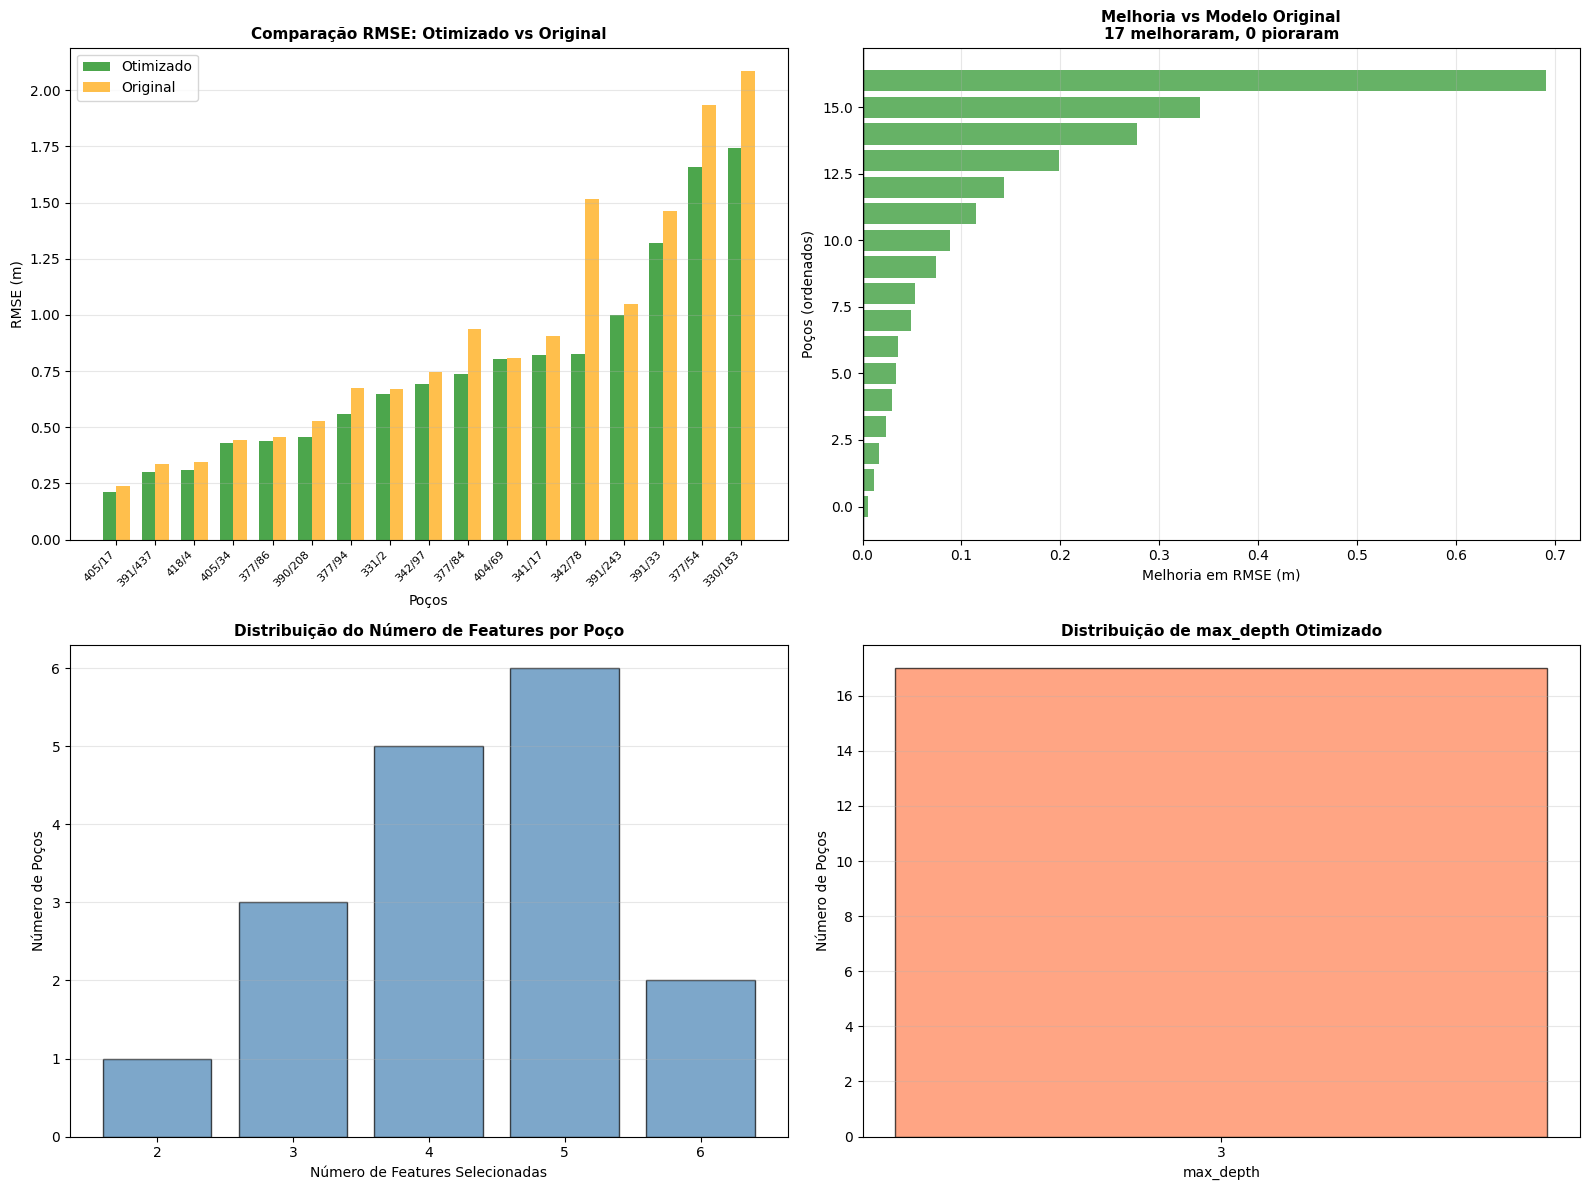

RESUMO ESTATÍSTICO DAS MELHORIAS

Melhoria em RMSE:
  Média: 0.1286 m
  Mediana: 0.0531 m
  Desvio padrão: 0.1741 m
  Min: 0.0056 m
  Max: 0.6909 m

Melhoria em MAE:
  Média: 0.0734 m
  Mediana: 0.0661 m

Melhoria em R²:
  Média: 0.8096
  Mediana: 0.1374

EXPORTAÇÃO DE RESULTADOS
✅ Resultados otimizados exportados: resultados_xgboost_otimizado_cv.csv
✅ Seleção de features exportada: feature_selection_por_poco.csv
✅ Hiperparâmetros otimizados exportados: hyperparams_otimizados_por_poco.csv
✅ Comparação otimizado vs original exportada: comparacao_otimizado_vs_original.csv

Total de poços processados: 17


In [7]:
# ============================================================================
# VISUALIZAÇÃO DAS MELHORIAS E EXPORTAÇÃO DE RESULTADOS
# ============================================================================

if 'metrics_optimized_df' in globals() and len(metrics_optimized_df) > 0:
    # Visualização comparativa
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Comparação RMSE: Otimizado vs Original
    ax1 = axes[0, 0]
    if 'metrics_original_df' in globals() and len(metrics_original_df) > 0:
        merged = metrics_optimized_df.merge(metrics_original_df, on=ID_COL, suffixes=('_opt', '_orig'))
        x_pos = np.arange(len(merged))
        width = 0.35
        
        ax1.bar(x_pos - width/2, merged['RMSE_opt'], width, label='Otimizado', color='green', alpha=0.7)
        ax1.bar(x_pos + width/2, merged['RMSE_orig'], width, label='Original', color='orange', alpha=0.7)
        ax1.set_xlabel('Poços', fontsize=10)
        ax1.set_ylabel('RMSE (m)', fontsize=10)
        ax1.set_title('Comparação RMSE: Otimizado vs Original', fontsize=11, fontweight='bold')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(merged[ID_COL], rotation=45, ha='right', fontsize=8)
        ax1.legend()
        ax1.grid(True, alpha=0.3, axis='y')
    
    # 2. Distribuição de melhorias em RMSE
    ax2 = axes[0, 1]
    if 'metrics_original_df' in globals() and len(metrics_original_df) > 0:
        improvements = merged['RMSE_improvement_vs_original']
        colors = ['green' if imp > 0 else 'red' for imp in improvements]
        ax2.barh(range(len(improvements)), improvements.sort_values(), color=colors, alpha=0.6)
        ax2.axvline(0, color='black', linestyle='-', linewidth=1)
        ax2.set_xlabel('Melhoria em RMSE (m)', fontsize=10)
        ax2.set_ylabel('Poços (ordenados)', fontsize=10)
        ax2.set_title(f'Melhoria vs Modelo Original\n{sum(improvements > 0)} melhoraram, {sum(improvements <= 0)} pioraram', 
                     fontsize=11, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='x')
    
    # 3. Número de features selecionadas por poço
    ax3 = axes[1, 0]
    if 'feature_selection_df' in globals() and len(feature_selection_df) > 0:
        n_features_counts = feature_selection_df['n_features'].value_counts().sort_index()
        ax3.bar(n_features_counts.index, n_features_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
        ax3.set_xlabel('Número de Features Selecionadas', fontsize=10)
        ax3.set_ylabel('Número de Poços', fontsize=10)
        ax3.set_title('Distribuição do Número de Features por Poço', fontsize=11, fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Hiperparâmetros mais usados
    ax4 = axes[1, 1]
    if 'hyperparams_df' in globals() and len(hyperparams_df) > 0:
        # Contar valores mais comuns de max_depth
        depth_counts = hyperparams_df['max_depth'].value_counts().sort_index()
        ax4.bar(depth_counts.index.astype(str), depth_counts.values, color='coral', alpha=0.7, edgecolor='black')
        ax4.set_xlabel('max_depth', fontsize=10)
        ax4.set_ylabel('Número de Poços', fontsize=10)
        ax4.set_title('Distribuição de max_depth Otimizado', fontsize=11, fontweight='bold')
        ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Resumo estatístico
    print("=" * 60)
    print("RESUMO ESTATÍSTICO DAS MELHORIAS")
    print("=" * 60)
    if 'metrics_original_df' in globals() and len(metrics_original_df) > 0:
        print(f"\nMelhoria em RMSE:")
        print(f"  Média: {merged['RMSE_improvement_vs_original'].mean():.4f} m")
        print(f"  Mediana: {merged['RMSE_improvement_vs_original'].median():.4f} m")
        print(f"  Desvio padrão: {merged['RMSE_improvement_vs_original'].std():.4f} m")
        print(f"  Min: {merged['RMSE_improvement_vs_original'].min():.4f} m")
        print(f"  Max: {merged['RMSE_improvement_vs_original'].max():.4f} m")
        
        print(f"\nMelhoria em MAE:")
        print(f"  Média: {merged['MAE_improvement_vs_original'].mean():.4f} m")
        print(f"  Mediana: {merged['MAE_improvement_vs_original'].median():.4f} m")
        
        print(f"\nMelhoria em R²:")
        print(f"  Média: {merged['R2_improvement_vs_original'].mean():.4f}")
        print(f"  Mediana: {merged['R2_improvement_vs_original'].median():.4f}")
    
    # Exportar resultados
    print("\n" + "=" * 60)
    print("EXPORTAÇÃO DE RESULTADOS")
    print("=" * 60)
    
    output_optimized = "resultados_xgboost_otimizado_cv.csv"
    metrics_optimized_df.to_csv(output_optimized, index=False)
    print(f"✅ Resultados otimizados exportados: {output_optimized}")
    
    if 'feature_selection_df' in globals() and len(feature_selection_df) > 0:
        output_features = "feature_selection_por_poco.csv"
        feature_selection_df.to_csv(output_features, index=False)
        print(f"✅ Seleção de features exportada: {output_features}")
    
    if 'hyperparams_df' in globals() and len(hyperparams_df) > 0:
        output_hyperparams = "hyperparams_otimizados_por_poco.csv"
        hyperparams_df.to_csv(output_hyperparams, index=False)
        print(f"✅ Hiperparâmetros otimizados exportados: {output_hyperparams}")
    
    if 'metrics_original_df' in globals() and len(metrics_original_df) > 0:
        output_comparison = "comparacao_otimizado_vs_original.csv"
        merged.to_csv(output_comparison, index=False)
        print(f"✅ Comparação otimizado vs original exportada: {output_comparison}")
    
    print(f"\nTotal de poços processados: {len(metrics_optimized_df)}")
    
else:
    print("⚠️  metrics_optimized_df não está disponível. Execute primeiro a célula de modelação otimizada.")



**Explicação:** Esta célula define uma função auxiliar que obtém o modelo otimizado para um poço específico:

**Função `get_optimized_model_for_well()`:**
- Procura nas tabelas de resultados se existe um modelo otimizado para o poço
- Se existir, extrai as features selecionadas e hiperparâmetros otimizados
- Treina o modelo usando esses parâmetros otimizados
- Se não existir, usa o modelo padrão (todas as features, parâmetros padrão)

**Retorna:**
- O modelo treinado
- Lista de features usadas
- Dicionário com hiperparâmetros
- Boolean indicando se usou modelo otimizado

Esta função é útil para visualizações e previsões futuras, garantindo que usamos sempre o melhor modelo disponível para cada poço.


In [8]:
# ============================================================================
# FUNÇÃO AUXILIAR: Obter modelo otimizado para um poço
# ============================================================================
# Esta função obtém as features e hiperparâmetros otimizados para um poço específico
# e retorna o modelo treinado usando esses parâmetros
# ============================================================================

def get_optimized_model_for_well(codigo: str, g: pd.DataFrame):
    """
    Obtém features e hiperparâmetros otimizados para um poço e retorna o modelo treinado.
    
    Returns:
        tuple: (model, best_features, best_params, use_optimized)
            - model: XGBRegressor treinado
            - best_features: lista de features selecionadas
            - best_params: dicionário com hiperparâmetros
            - use_optimized: bool indicando se usou modelo otimizado
    """
    use_optimized = False
    best_features = None
    best_params = None
    
    # Tentar obter modelo otimizado
    if 'feature_selection_df' in globals() and 'hyperparams_df' in globals():
        feature_row = feature_selection_df[feature_selection_df[ID_COL] == codigo]
        hyperparams_row = hyperparams_df[hyperparams_df[ID_COL] == codigo]
        
        if len(feature_row) > 0 and len(hyperparams_row) > 0:
            use_optimized = True
            # Extrair features selecionadas
            features_str = feature_row['features_selected'].iloc[0]
            best_features = [f.strip() for f in features_str.split(',')]
            
            # Extrair hiperparâmetros otimizados
            best_params = {
                'max_depth': int(hyperparams_row['max_depth'].iloc[0]),
                'learning_rate': float(hyperparams_row['learning_rate'].iloc[0]),
                'n_estimators': int(hyperparams_row['n_estimators'].iloc[0]),
                'subsample': float(hyperparams_row['subsample'].iloc[0]),
                'objective': 'reg:squarederror',
                'random_state': RANDOM_SEED,
                'n_jobs': N_JOBS,
            }
    
    # Se não houver modelo otimizado, usar padrão
    if not use_optimized:
        best_features = [c for c in XREG_COLS if c in g.columns]
        best_params = XGB_PARAMS.copy()
    
    # Treinar modelo
    X_all = g[best_features].to_numpy()
    y_all = g[TARGET_COL].to_numpy()
    
    model = XGBRegressor(**best_params)
    model.fit(X_all, y_all)
    
    return model, best_features, best_params, use_optimized

print("✅ Função auxiliar get_optimized_model_for_well() definida com sucesso!")



✅ Função auxiliar get_optimized_model_for_well() definida com sucesso!


**Explicação:** Esta célula cria uma visualização interativa por poço usando o modelo otimizado:

**Função `plot_for_codigo_optimized()`:**
- Obtém o modelo otimizado para o poço selecionado (se disponível)
- Divide os dados em treino/teste (80%/20%)
- Treina o modelo no conjunto de treino
- Faz previsões no conjunto de teste
- Calcula métricas (RMSE, MAE, MAPE, R²)

**Gráficos gerados:**
1. **Série temporal:** Mostra dados observados, previsões do modelo otimizado e baseline de persistência
2. **Resíduos:** Mostra a diferença entre valores observados e previstos ao longo do tempo

**Informações impressas:**
- Estatísticas dos resíduos (média, desvio padrão, min, max)
- Features e hiperparâmetros usados (se modelo otimizado)

Se tiver `ipywidgets` instalado, aparece um dropdown para escolher o poço interativamente.

---

<div style="background-color: #e3f2fd; color: #000000; padding: 15px; border-left: 4px solid #2196F3; margin: 10px 0;">

**📚 Teórica:**

**Análise de Resíduos:** Os resíduos são definidos como e_i = y_i - ŷ_i, onde y_i são valores observados e ŷ_i são previsões. Um bom modelo deve ter resíduos com: (1) média próxima de zero (E[e] ≈ 0), indicando ausência de viés sistemático; (2) variância constante (homocedasticidade); (3) distribuição aproximadamente normal; (4) sem padrões temporais (ruído branco). Se os resíduos mostrarem tendências ou padrões, o modelo pode estar subestimando ou superestimando sistematicamente em certos períodos.

**Avaliação no Conjunto de Teste:** O modelo é treinado apenas no conjunto de treino (80% dos dados) e avaliado no conjunto de teste (20% mais recente). Isto simula condições reais onde o modelo é usado para prever dados nunca vistos durante o treino. As métricas calculadas (RMSE, MAE, MAPE, R²) no conjunto de teste são estimativas não enviesadas da performance esperada em produção.

</div>


In [ ]:
# ============================================================================
# VISUALIZAÇÃO INTERATIVA POR POÇO (USANDO MODELO OTIMIZADO COM CV)
# ============================================================================
# Esta célula substitui a visualização antiga e usa automaticamente o modelo
# otimizado (com features selecionadas e hiperparâmetros ajustados) se disponível
# ============================================================================

try:
    from ipywidgets import interact, widgets
    has_widgets = True
except Exception:
    has_widgets = False
    print("Para filtro interativo, instale ipywidgets: %pip install ipywidgets")

codes = sorted(df[ID_COL].dropna().unique().tolist())

# Priorizar modelo otimizado se disponível
default_code = (
    metrics_optimized_df[ID_COL].iloc[0]
    if 'metrics_optimized_df' in globals() and len(metrics_optimized_df) > 0
    else (metrics_df[ID_COL].iloc[0]
          if 'metrics_df' in globals() and len(metrics_df) > 0
          else (codes[0] if len(codes) > 0 else None))
)


def plot_for_codigo_optimized(codigo):
    """Visualização usando modelo otimizado com CV."""
    if codigo is None:
        return

    g = df[df[ID_COL] == codigo].sort_values(DATE_COL).reset_index(drop=True)
    if len(g) < MIN_SERIES_LENGTH:
        print(f"Poço {codigo}: série curta ({len(g)} observações).")
        return

    # Obter modelo otimizado
    model_full, best_features, best_params, use_optimized = get_optimized_model_for_well(codigo, g)
    
    if not best_features:
        print(f"Poço {codigo}: não há variáveis exógenas disponíveis.")
        return

    if g[best_features + [TARGET_COL]].isna().any().any():
        print(f"Poço {codigo}: existem NAs nas features/target mesmo após limpeza.")
        return

    train_df, test_df = temporal_split(g, TEST_FRACTION)

    y_train = train_df[TARGET_COL].to_numpy()
    y_test = test_df[TARGET_COL].to_numpy()
    X_train = train_df[best_features].to_numpy()
    X_test = test_df[best_features].to_numpy()

    # Treinar modelo no conjunto de treino (usando parâmetros otimizados)
    model = XGBRegressor(**best_params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Baseline de persistência
    y_pred_persist = np.r_[y_train[-1], y_test[:-1]]

    # Métricas
    rmse_val = rmse(y_test, y_pred)
    mae_val = float(mean_absolute_error(y_test, y_pred))
    mape_val = mape(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)
    rmse_base_val = rmse(y_test, y_pred_persist)

    # Figura com 2 subplots
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # Série temporal
    ax1 = axes[0]
    model_label = "Forecast (XGBoost Otimizado - CV)" if use_optimized else "Forecast (XGBoost)"
    ax1.plot(g[DATE_COL], g[TARGET_COL], label="Observado", color="C0", linewidth=1.5, marker='o', markersize=3)
    ax1.axvline(test_df[DATE_COL].iloc[0], color="k", linestyle="--", alpha=0.6, linewidth=2, label="Split Train/Test")
    ax1.plot(test_df[DATE_COL], y_pred, label=model_label, color="C3", linewidth=2, marker='s', markersize=4)
    ax1.plot(test_df[DATE_COL], y_pred_persist, label="Baseline (Persistência)", color="C2", alpha=0.7,
             linewidth=1.5, linestyle='--')
    title_suffix = " (Otimizado com CV)" if use_optimized else ""
    ax1.set_title(
        f"Poço {codigo} - XGBoost{title_suffix}\n"
        f"RMSE={rmse_val:.3f} | MAE={mae_val:.3f} | MAPE={mape_val:.2f}% | R²={r2_val:.3f}\n"
        f"Baseline RMSE={rmse_base_val:.3f} | Ganho RMSE={rmse_base_val - rmse_val:.3f}",
        fontsize=11, fontweight='bold'
    )
    ax1.invert_yaxis()
    ax1.set_ylabel("Profundidade (m)", fontsize=10)
    ax1.legend(loc='best', fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Resíduos
    ax2 = axes[1]
    residuals = y_test - y_pred
    ax2.plot(test_df[DATE_COL], residuals, 'o-', color='C4', markersize=4, linewidth=1)
    ax2.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax2.set_title("Resíduos (Observado - Previsto)", fontsize=10, fontweight='bold')
    ax2.set_xlabel("Data", fontsize=10)
    ax2.set_ylabel("Resíduo (m)", fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nEstatísticas dos resíduos para poço {codigo}:")
    print(f"  Média: {np.mean(residuals):.4f} m")
    print(f"  Desvio padrão: {np.std(residuals):.4f} m")
    print(f"  Min: {np.min(residuals):.4f} m")
    print(f"  Max: {np.max(residuals):.4f} m")
    
    if use_optimized:
        print(f"\n📊 Modelo otimizado usado:")
        print(f"   Features: {best_features}")
        print(f"   max_depth={best_params['max_depth']}, lr={best_params['learning_rate']:.3f}, "
              f"n_est={best_params['n_estimators']}, subsample={best_params['subsample']:.2f}")


if has_widgets and default_code is not None and len(codes) > 0:
    interact(
        plot_for_codigo_optimized,
        codigo=widgets.Dropdown(options=codes, value=default_code, description='poço')
    )
elif default_code is not None:
    plot_for_codigo_optimized(default_code)



interactive(children=(Dropdown(description='poço', index=14, options=('330/183', '331/2', '341/17', '342/78', …

**Explicação:** Esta célula gera **previsões futuras** (12 meses à frente) usando o modelo otimizado:

**Processo:**
1. Para cada poço, obtém o modelo otimizado (features selecionadas + hiperparâmetros ajustados)
2. Treina o modelo em **TODA** a série histórica desse poço (não apenas treino, mas todos os dados disponíveis)
3. Gera datas futuras (próximos 12 meses)
4. Para as features futuras, usa o padrão dos últimos 12 meses históricos (assumindo comportamento similar)

**Limitações:**
- As previsões futuras dependem das features exógenas (lags de precipitação, evapotranspiração, caudal)
- Como não temos valores futuros reais destas variáveis, usamos valores históricos recentes
- Em produção, seria necessário ter previsões meteorológicas/hidrológicas para as features

**Resultado:**
- DataFrame com previsões de profundidade para os próximos 12 meses para cada poço
- Exportado para `previsoes_xgboost_otimizado_cv_12m.csv`

**Nota:** O horizonte de 12 meses pode ser alterado modificando a variável `FORECAST_HORIZON`.

---

<div style="background-color: #e3f2fd; color: #000000; padding: 15px; border-left: 4px solid #2196F3; margin: 10px 0;">

**📚 Teórica:**

**Forecasting com Modelos Supervisionados:** O XGBoost é um modelo supervisionado que aprende a função f: X → y, onde X são as features (lags) e y é a variável alvo (profundidade). Para prever y(t+h) no futuro, precisamos de X(t+h), mas estas features são lags de variáveis exógenas (precipitação, evapotranspiração, caudal) que também são desconhecidas no futuro.

**Abordagem de Cenário (Scenario-based Forecasting):** Como não temos valores futuros reais das variáveis exógenas, usamos um cenário assumindo que o próximo período terá comportamento similar ao passado recente. Especificamente: X_future(t+h) = X_histórico(t+h-12) para h = 1, ..., 12, onde t é o último mês histórico. Isto é uma simplificação: em produção, deveria-se usar previsões meteorológicas/hidrológicas ou múltiplos cenários (otimista, pessimista, médio).

**Treino em Toda a Série Histórica:** Para forecasting, treina-se o modelo em TODOS os dados disponíveis (não apenas treino), pois queremos maximizar a informação usada para aprender padrões. O modelo final é: ŷ(t+h) = XGBoost(X_future(t+h), θ*), onde θ* são os hiperparâmetros otimizados. A incerteza aumenta com o horizonte h devido à propagação de erros e à incerteza nas features futuras.

</div>


In [10]:
# ============================================================================
# PREVISÕES FUTURAS COM MODELO OTIMIZADO (CV)
# ============================================================================
# Gera previsões futuras usando o modelo otimizado (features selecionadas
# e hiperparâmetros ajustados) para cada poço
# ============================================================================

# Número de meses a prever (podes alterar para 6, 12, etc.)
FORECAST_HORIZON = 12  # meses

future_forecasts_optimized = []

for codigo, g in tqdm(df.groupby(ID_COL), total=df[ID_COL].nunique(), desc="Gerando previsões"):
    g = g.sort_values(DATE_COL).reset_index(drop=True)

    if len(g) < MIN_SERIES_LENGTH:
        continue

    # Obter modelo otimizado para este poço
    model_full, best_features, best_params, use_optimized = get_optimized_model_for_well(codigo, g)
    
    if not best_features:
        continue

    if g[best_features + [TARGET_COL]].isna().any().any():
        continue

    # Treinar modelo XGBoost em TODA a série histórica desse poço (com parâmetros otimizados)
    X_all = g[best_features].to_numpy()
    y_all = g[TARGET_COL].to_numpy()

    model = XGBRegressor(**best_params)
    model.fit(X_all, y_all)

    # Construir datas futuras (mesmo esquema de datas mensais)
    last_date = g[DATE_COL].iloc[-1]
    # Usa início de mês (freq="MS") para ser consistente com o reindex mensal
    future_dates = pd.date_range(
        last_date.to_period("M").to_timestamp(),
        periods=FORECAST_HORIZON + 1,
        freq="MS",
    )[1:]  # remover a própria last_date

    # CENÁRIO PARA AS FEATURES FUTURAS:
    # usamos o padrão dos últimos FORECAST_HORIZON meses de variáveis exógenas,
    # assumindo que o próximo ano terá um comportamento semelhante.
    hist_feats = g[best_features].tail(FORECAST_HORIZON).to_numpy()
    if len(hist_feats) < FORECAST_HORIZON:
        # se a série for mais curta que o horizonte, repetimos o último valor
        last_row = hist_feats[-1:].copy()
        extra = np.repeat(last_row, FORECAST_HORIZON - len(hist_feats), axis=0)
        X_future = np.vstack([hist_feats, extra])
    else:
        X_future = hist_feats.copy()

    y_future = model.predict(X_future)

    for h, (dt, y_hat) in enumerate(zip(future_dates, y_future), start=1):
        future_forecasts_optimized.append(
            {
                ID_COL: codigo,
                DATE_COL: dt,
                "horizon_months": h,
                "y_hat_xgb_optimized": float(y_hat),
                "used_optimized": use_optimized,
            }
        )

forecast_optimized_df = pd.DataFrame(future_forecasts_optimized)

print("=" * 60)
print("PREVISÕES FUTURAS (XGBoost OTIMIZADO com CV) POR POÇO")
print("=" * 60)
print(f"Poços com previsão gerada: {forecast_optimized_df[ID_COL].nunique()}")
print(f"Total de pontos de previsão: {len(forecast_optimized_df)}")
print(f"Poços usando modelo otimizado: {forecast_optimized_df['used_optimized'].sum()}")
print("\nExemplo de previsões (primeiras linhas):")
display(forecast_optimized_df.head(20))

# Exportar previsões
output_forecast_csv = "previsoes_xgboost_otimizado_cv_12m.csv"
forecast_optimized_df.to_csv(output_forecast_csv, index=False)
print(f"\n✅ Previsões futuras (otimizadas) exportadas para: {output_forecast_csv}")
print("Para obter apenas 6 meses, podes filtrar: forecast_optimized_df[forecast_optimized_df['horizon_months'] <= 6]")



Gerando previsões:   0%|          | 0/17 [00:00<?, ?it/s]

PREVISÕES FUTURAS (XGBoost OTIMIZADO com CV) POR POÇO
Poços com previsão gerada: 17
Total de pontos de previsão: 204
Poços usando modelo otimizado: 204

Exemplo de previsões (primeiras linhas):


,codigo,ym,horizon_months,y_hat_xgb_optimized,used_optimized
0,330/183,2024-07-01,1,3.041766,True
1,330/183,2024-08-01,2,3.072352,True
2,330/183,2024-09-01,3,4.287115,True
3,330/183,2024-10-01,4,1.992135,True
4,330/183,2024-11-01,5,1.664535,True
5,330/183,2024-12-01,6,1.338975,True
6,330/183,2025-01-01,7,1.248138,True
7,330/183,2025-02-01,8,1.107114,True
8,330/183,2025-03-01,9,1.237589,True
9,330/183,2025-04-01,10,1.233354,True



✅ Previsões futuras (otimizadas) exportadas para: previsoes_xgboost_otimizado_cv_12m.csv
Para obter apenas 6 meses, podes filtrar: forecast_optimized_df[forecast_optimized_df['horizon_months'] <= 6]


**Explicação:** Esta célula cria uma visualização interativa das previsões futuras (histórico + forecast):

**Função `plot_forecast_for_codigo_optimized()`:**
- Mostra a série histórica completa (dados observados)
- Mostra as previsões futuras (próximos 12 meses, ou menos se ajustado)
- Linha vertical marca o ponto onde termina o histórico e começam as previsões

**Características:**
- Interativa: dropdown para escolher o poço
- Slider para ajustar o horizonte de previsão (1 a 12 meses)
- Usa o modelo otimizado (forecast_optimized_df)
- Útil para visualizar como as previsões se conectam com o histórico

**Porquê é útil:**
- Permite verificar se as previsões fazem sentido (continuidade com histórico)
- Identifica tendências futuras
- Facilita a apresentação de resultados a stakeholders

---

<div style="background-color: #e3f2fd; color: #000000; padding: 15px; border-left: 4px solid #2196F3; margin: 10px 0;">

**📚 Teórica:**

**Visualização de Forecast:** O gráfico mostra a série temporal completa: y_histórico(t) para t ≤ T (dados observados) e ŷ_futuro(t+h) para h = 1, ..., H (previsões). A linha vertical em t = T marca o "ponto de corte" entre passado (conhecido) e futuro (previsto). A continuidade visual entre histórico e forecast é importante: se houver descontinuidade abrupta, pode indicar problemas no modelo ou nas features futuras usadas.

**Interpretação das Previsões:** As linhas de forecast são geradas aplicando o modelo treinado aos cenários de features futuras: ŷ(t+h) = f(X_future(t+h)). Como X_future é baseado em padrões históricos recentes, as previsões tendem a seguir tendências e sazonalidades aprendidas do histórico. A incerteza não é mostrada explicitamente (seria necessário intervalos de confiança ou múltiplos cenários), mas aumenta com o horizonte h devido à propagação de erros.

</div>


In [11]:
# ============================================================================
# VISUALIZAÇÃO DAS PREVISÕES FUTURAS (HISTÓRICO + FORECAST)
# ============================================================================
# Mostra gráfico com série histórica + previsões futuras de 12 meses
# usando o modelo otimizado
# ============================================================================

if 'forecast_optimized_df' not in globals() or len(forecast_optimized_df) == 0:
    print("⚠️  forecast_optimized_df não está definido ou está vazio. Execute primeiro a célula de previsões futuras.")
else:
    try:
        from ipywidgets import interact, widgets
        has_widgets_forecast = True
    except Exception:
        has_widgets_forecast = False
        print("Para visualização interativa, instale ipywidgets: %pip install ipywidgets")

    codes_forecast = sorted(forecast_optimized_df[ID_COL].dropna().unique().tolist())

    def plot_forecast_for_codigo_optimized(codigo, horizon_months=12):
        """Visualização de previsões futuras usando modelo otimizado."""
        if codigo is None:
            return

        # Histórico deste poço
        g_hist = df[df[ID_COL] == codigo].sort_values(DATE_COL).reset_index(drop=True)
        if g_hist.empty:
            print(f"Não há histórico para poço {codigo}.")
            return

        # Previsões futuras para este poço (usando modelo otimizado)
        g_fut = (
            forecast_optimized_df[(forecast_optimized_df[ID_COL] == codigo) & 
                                  (forecast_optimized_df["horizon_months"] <= horizon_months)]
            .sort_values(DATE_COL)
            .reset_index(drop=True)
        )
        if g_fut.empty:
            print(f"Não há previsões futuras para poço {codigo} (verifica FORECAST_HORIZON).")
            return

        fig, ax = plt.subplots(figsize=(14, 6))

        # Série histórica
        ax.plot(
            g_hist[DATE_COL],
            g_hist[TARGET_COL],
            label="Histórico (observado)",
            color="C0",
            linewidth=1.8,
            marker="o",
            markersize=3,
        )

        # Linha vertical no ponto de corte
        last_hist_date = g_hist[DATE_COL].iloc[-1]
        ax.axvline(last_hist_date, color="k", linestyle="--", alpha=0.6, linewidth=2, label="Início da previsão")

        # Previsões futuras (modelo otimizado)
        ax.plot(
            g_fut[DATE_COL],
            g_fut["y_hat_xgb_optimized"],
            label="Previsão futura (XGBoost Otimizado)",
            color="C3",
            linewidth=2.5,
            marker="s",
            markersize=5,
        )

        ax.invert_yaxis()  # profundidade aumenta para baixo
        ax.set_title(
            f"Poço {codigo} - Previsões futuras XGBoost Otimizado (até {horizon_months} meses)",
            fontsize=12,
            fontweight="bold",
        )
        ax.set_xlabel("Data", fontsize=11)
        ax.set_ylabel("Profundidade (m)", fontsize=11)
        ax.legend(loc="best", fontsize=10)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    if 'has_widgets_forecast' in globals() and has_widgets_forecast and len(codes_forecast) > 0:
        interact(
            plot_forecast_for_codigo_optimized,
            codigo=widgets.Dropdown(options=codes_forecast, value=codes_forecast[0], description="poço"),
            horizon_months=widgets.IntSlider(min=1, max=FORECAST_HORIZON, step=1, value=FORECAST_HORIZON,
                                             description="horizonte (meses)"),
        )
    elif len(codes_forecast) > 0:
        # fallback: mostra o primeiro poço com horizonte completo
        plot_forecast_for_codigo_optimized(codes_forecast[0], horizon_months=FORECAST_HORIZON)


interactive(children=(Dropdown(description='poço', options=('330/183', '331/2', '341/17', '342/78', '342/97', …

<div style="background-color: #FFFFFF; padding: 40px 50px; margin: 20px 0; box-shadow: 0 2px 8px rgba(0,0,0,0.1); border: 1px solid #E0E0E0; border-radius: 4px; max-width: 210mm; min-height: 297mm; color: #000000;">

# Resumo do Notebook modelo2_limpo.ipynb

## 1. Objetivo e contexto

- **Modelo XGBoost** para prever profundidade de água subterrânea por poço
- **Variável alvo:** `profundidade` (metros)
- **Variáveis exógenas:** 6 lags (precipitação, evapotranspiração, caudal com 1 e 2 meses de atraso)
- **17 poços** selecionados para modelação
- **Split temporal:** 80% treino / 20% teste (respeitando ordem cronológica)

## 2. Melhorias com Cross-Validation

- **Time Series Cross-Validation:** avaliação respeitando ordem temporal
- **Seleção de features por poço:** otimização individual usando CV
- **Tuning de hiperparâmetros por poço:** ajuste individual usando CV
- **Comparação automática:** modelo otimizado vs original

## 3. Preparação de dados

- **Carregamento do CSV** com dados mensais por poço
- **Reindex mensal:** preenchimento de gaps temporais
- **Tratamento de NAs:**
  - Interpolação linear nas variáveis base (rr, eto, caudal)
  - Remoção de linhas com NAs nas features de lag e na variável alvo
- **Filtragem:** apenas poços selecionados

## 4. Funções auxiliares

- `temporal_split()`: divisão temporal treino/teste
- `fit_predict_xgboost()`: treino e previsão com XGBoost
- `time_series_cv_split()`: geração de splits temporais para CV
- `evaluate_model_cv()`: avaliação com Time Series Cross-Validation

## 5. Otimização por poço

**Seleção de features:**
- Testa combinações de features usando CV
- Seleciona o subconjunto que minimiza RMSE no CV

**Tuning de hiperparâmetros:**
- Grid search limitado (20 combinações)
- Parâmetros: `max_depth`, `learning_rate`, `n_estimators`, `subsample`
- Seleciona a combinação que minimiza RMSE no CV

## 6. Loop principal de modelação

Para cada poço:
1. Seleção de features com CV
2. Tuning de hiperparâmetros com CV
3. Treino de dois modelos:
   - Modelo otimizado (features selecionadas + hiperparâmetros ajustados)
   - Modelo original (todas as features + parâmetros padrão)
4. Avaliação: RMSE, MAE, MAPE, R²
5. Comparação com baseline de persistência

## 7. Métricas e avaliação

- **Métricas calculadas:** RMSE, MAE, MAPE, R²
- **Comparações:**
  - Modelo otimizado vs original
  - Modelo otimizado vs baseline (persistência)
- **Resultados:** melhoria média de **0.1286 m** em RMSE

## 8. Visualizações

**Gráficos comparativos:**
- RMSE: otimizado vs original
- Distribuição de melhorias
- Número de features selecionadas por poço
- Distribuição de hiperparâmetros otimizados

**Visualização interativa por poço:**
- Série temporal (observado, forecast, baseline)
- Análise de resíduos
- Dropdown para seleção de poço

## 9. Previsões futuras

- **Horizonte:** 12 meses à frente
- **Processo:**
  - Treino em toda a série histórica (não apenas treino)
  - Uso de padrões históricos recentes para features futuras
  - Aplicação do modelo otimizado por poço
- **Exportação:** `previsoes_xgboost_otimizado_cv_12m.csv`

## 10. Visualização de previsões futuras

**Gráfico histórico + forecast:**
- Série histórica completa
- Previsões futuras (12 meses)
- Linha vertical marcando o ponto de corte

**Interatividade:**
- Dropdown para seleção de poço
- Slider para ajustar horizonte (1-12 meses)

## 11. Exportação de resultados

**Ficheiros CSV gerados:**
- `resultados_xgboost_otimizado_cv.csv`: métricas completas do modelo otimizado
- `feature_selection_por_poco.csv`: features selecionadas por poço
- `hyperparams_otimizados_por_poco.csv`: hiperparâmetros otimizados por poço
- `comparacao_otimizado_vs_original.csv`: comparação direta entre modelos
- `previsoes_xgboost_otimizado_cv_12m.csv`: previsões futuras (12 meses)

</div>

